# Exploration, nettoyage et fusion des donnees Agritech

Ce notebook documente la procedure d'exploration des donnees, de nettoyage, de transformation, d'encodage et de fusion pour repondre a la premiere partie de la mission.

Objectifs :
- comprendre les deux familles de datasets disponibles ;
- identifier les cles de jointure pertinentes ;
- nettoyer et standardiser les colonnes ;
- construire un dataset consolide exploitable pour l'entrainement ;
- preparer les transformations de features pour la modelisation ;
- produire une ACP interpretable sur le dataset agronomique `crop_yield.csv`.

## Plan

1. Chargement et cadrage des sources
2. Audit rapide des schemas, doublons et valeurs manquantes
3. Standardisation des cles geographiques et temporelles
4. Construction du dataset consolide
5. Controles qualite post-fusion
6. Preparation des transformations pour le modele
7. ACP sur le dataset agronomique complementaire
8. Synthese metier et technique

In [26]:
from pathlib import Path

import json

import re

import unicodedata



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer

from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler



plt.style.use('ggplot')

pd.set_option('display.max_columns', 50)

pd.set_option('display.max_rows', 100)



ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]

ROOT = next((path for path in ROOT_CANDIDATES if (path / 'DATA').exists()), Path.cwd())

DATA_DIR = ROOT / 'DATA'

ARTIFACTS_DIR = ROOT / 'artifacts'

ARTIFACTS_DATA_DIR = ARTIFACTS_DIR / 'data'

ARTIFACTS_REPORTS_DIR = ARTIFACTS_DIR / 'reports'

ARTIFACTS_DATA_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_REPORTS_DIR.mkdir(parents=True, exist_ok=True)



ROOT


PosixPath('/app')

In [27]:
AREA_ALIASES = {
    'bolivia plurinational state of': 'bolivia',
    'cote divoire': 'cote d ivoire',
    'democratic republic of the congo': 'democratic republic of congo',
    'iran islamic republic of': 'iran',
    'lao peoples democratic republic': 'laos',
    'republic of moldova': 'moldova',
    'syrian arab republic': 'syria',
    'the former yugoslav republic of macedonia': 'north macedonia',
    'united kingdom of great britain and northern ireland': 'united kingdom',
    'united republic of tanzania': 'tanzania',
    'united states of america': 'united states',
    'venezuela bolivarian republic of': 'venezuela',
    'viet nam': 'vietnam',
}

def normalize_area_key(value: str) -> str:
    normalized = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode('ascii')
    normalized = normalized.lower()
    normalized = re.sub(r'[^a-z0-9]+', ' ', normalized).strip()
    return AREA_ALIASES.get(normalized, normalized)

def prepare_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame.columns = [column.strip() for column in frame.columns]
    return frame

def describe_frame(name: str, frame: pd.DataFrame) -> dict:
    return {
        'dataset': name,
        'rows': int(frame.shape[0]),
        'columns': int(frame.shape[1]),
        'duplicate_rows': int(frame.duplicated().sum()),
        'missing_cells': int(frame.isna().sum().sum()),
    }

In [28]:
raw_frames = {
    'crop_yield_prediction': pd.read_csv(DATA_DIR / 'crop_yield.csv'),
    'historical_yield': pd.read_csv(DATA_DIR / 'yield.csv'),
    'rainfall': pd.read_csv(DATA_DIR / 'rainfall.csv'),
    'pesticides': pd.read_csv(DATA_DIR / 'pesticides.csv'),
    'temperature': pd.read_csv(DATA_DIR / 'temp.csv'),
}

summary_table = pd.DataFrame([describe_frame(name, frame) for name, frame in raw_frames.items()])
summary_table

,dataset,rows,columns,duplicate_rows,missing_cells
0,crop_yield_prediction,1000000,10,0,0
1,historical_yield,56717,12,0,0
2,rainfall,6727,3,0,774
3,pesticides,4349,7,0,0
4,temperature,71311,3,6958,2547


In [29]:
for name, frame in raw_frames.items():
    print(f'\n### {name}')
    display(frame.head(3))
    print(frame.dtypes)


### crop_yield_prediction


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443


Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

### historical_yield


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260


Domain Code     object
Domain          object
Area Code        int64
Area            object
Element Code     int64
Element         object
Item Code        int64
Item            object
Year Code        int64
Year             int64
Unit            object
Value            int64
dtype: object

### rainfall


...

 Area                            object
Year                              int64
average_rain_fall_mm_per_year    object
dtype: object

### pesticides


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0


Domain      object
Area        object
Element     object
Item        object
Year         int64
Unit        object
Value      float64
dtype: object

### temperature


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67


year          int64
country      object
avg_temp    float64
dtype: object


## Strategie retenue

Le projet contient en pratique deux familles de donnees :

- `yield.csv` + `rainfall.csv` + `pesticides.csv` + `temp.csv` : ce bloc est exploitable pour construire le dataset consolide de prediction car il partage des dimensions geographiques et temporelles (`Area/country`, `Year/year`).
- `crop_yield.csv` : dataset agronomique complementaire tres volumineux, utile pour valider les facteurs explicatifs, illustrer les distributions et realiser une ACP orientee interpretabilite.

La cle de jointure retenue pour le dataset source de verite est donc :
- geographie normalisee via `area_key` ;
- annee via `Year`.

La culture (`Item`) reste la dimension cible du probleme de prediction / recommandation.

In [30]:
missing_ratio = pd.DataFrame({
    name: frame.isna().mean().sort_values(ascending=False).head(10)
    for name, frame in raw_frames.items()
}).fillna(0)
missing_ratio

,crop_yield_prediction,historical_yield,rainfall,pesticides,temperature
Area,0.0,0.0,0.000000,0.0,0.000000
Area,0.0,0.0,0.000000,0.0,0.000000
Area Code,0.0,0.0,0.000000,0.0,0.000000
Crop,0.0,0.0,0.000000,0.0,0.000000
Days_to_Harvest,0.0,0.0,0.000000,0.0,0.000000
Domain,0.0,0.0,0.000000,0.0,0.000000
Domain Code,0.0,0.0,0.000000,0.0,0.000000
Element,0.0,0.0,0.000000,0.0,0.000000
Element Code,0.0,0.0,0.000000,0.0,0.000000
Fertilizer_Used,0.0,0.0,0.000000,0.0,0.000000


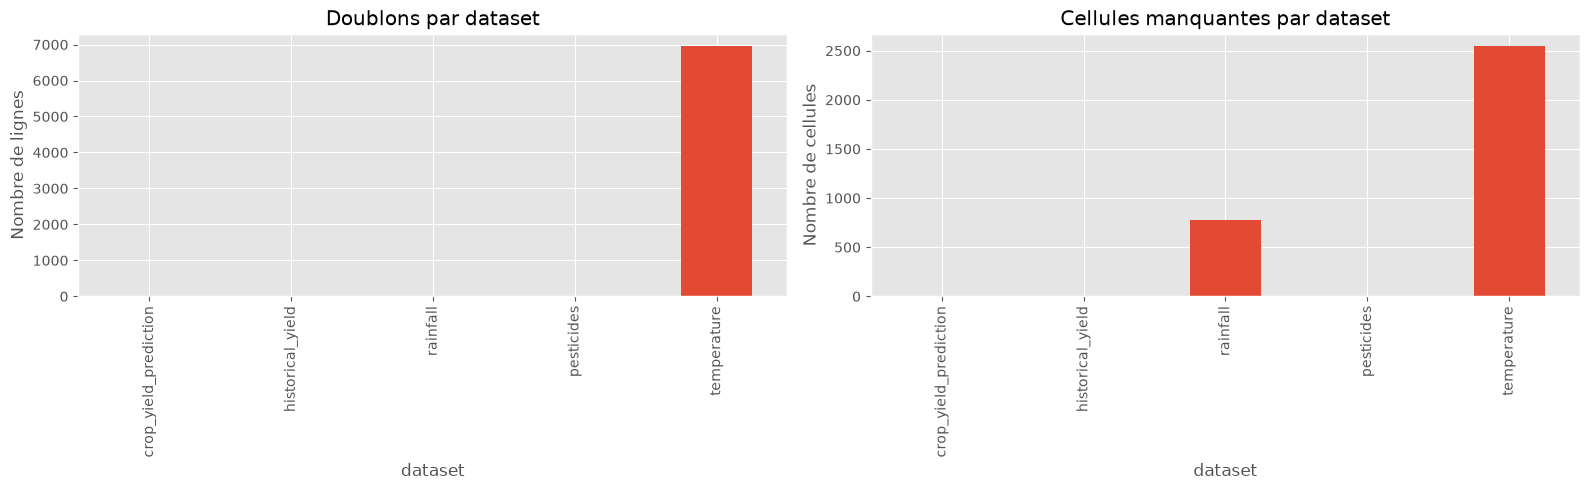

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
summary_table.set_index('dataset')['duplicate_rows'].plot(kind='bar', ax=axes[0], title='Doublons par dataset')
summary_table.set_index('dataset')['missing_cells'].plot(kind='bar', ax=axes[1], title='Cellules manquantes par dataset')
axes[0].set_ylabel('Nombre de lignes')
axes[1].set_ylabel('Nombre de cellules')
plt.tight_layout()

In [32]:
historical_yield = prepare_frame(raw_frames['historical_yield']).rename(columns={'Value': 'hg_ha_yield'})
historical_yield = historical_yield[['Area', 'Item', 'Year', 'hg_ha_yield']].copy()
historical_yield['area_key'] = historical_yield['Area'].map(normalize_area_key)

rainfall = prepare_frame(raw_frames['rainfall'])
rainfall['area_key'] = rainfall['Area'].map(normalize_area_key)
rainfall['average_rain_fall_mm_per_year'] = pd.to_numeric(rainfall['average_rain_fall_mm_per_year'], errors='coerce')
rainfall = rainfall[['area_key', 'Year', 'average_rain_fall_mm_per_year']]

pesticides = prepare_frame(raw_frames['pesticides']).rename(columns={'Value': 'pesticides_tonnes'})
pesticides['area_key'] = pesticides['Area'].map(normalize_area_key)
pesticides['pesticides_tonnes'] = pd.to_numeric(pesticides['pesticides_tonnes'], errors='coerce')
pesticides = pesticides[['area_key', 'Year', 'pesticides_tonnes']]

temperature = prepare_frame(raw_frames['temperature']).rename(columns={'year': 'Year', 'country': 'Area'})
temperature['area_key'] = temperature['Area'].map(normalize_area_key)
temperature['avg_temp'] = pd.to_numeric(temperature['avg_temp'], errors='coerce')
temperature = temperature[['area_key', 'Year', 'avg_temp']]

crop_yield = prepare_frame(raw_frames['crop_yield_prediction']).copy()
crop_yield['Fertilizer_Used'] = crop_yield['Fertilizer_Used'].astype(int)
crop_yield['Irrigation_Used'] = crop_yield['Irrigation_Used'].astype(int)

display(historical_yield.head())
display(crop_yield.head())

,Area,Item,Year,hg_ha_yield,area_key
0,Afghanistan,Maize,1961,14000,afghanistan
1,Afghanistan,Maize,1962,14000,afghanistan
2,Afghanistan,Maize,1963,14260,afghanistan
3,Afghanistan,Maize,1964,14257,afghanistan
4,Afghanistan,Maize,1965,14400,afghanistan


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


In [33]:
coverage = {
    'yield_area_year': set(historical_yield[['area_key', 'Year']].itertuples(index=False, name=None)),
    'rainfall_area_year': set(rainfall[['area_key', 'Year']].itertuples(index=False, name=None)),
    'pesticides_area_year': set(pesticides[['area_key', 'Year']].itertuples(index=False, name=None)),
    'temperature_area_year': set(temperature[['area_key', 'Year']].itertuples(index=False, name=None)),
}

coverage_report = pd.DataFrame({
    'pairs': [len(values) for values in coverage.values()],
}, index=list(coverage.keys()))

coverage_report['coverage_vs_yield'] = [
    len(coverage['yield_area_year'] & coverage[key]) / len(coverage['yield_area_year'])
    for key in coverage_report.index
]
coverage_report

,pairs,coverage_vs_yield
yield_area_year,10572,1.000000
rainfall_area_year,6727,0.480609
pesticides_area_year,4349,0.408437
temperature_area_year,28514,0.577090


In [ ]:
merged = historical_yield.merge(rainfall, on=['area_key', 'Year'], how='left')
merged = merged.merge(pesticides, on=['area_key', 'Year'], how='left')
merged = merged.merge(temperature, on=['area_key', 'Year'], how='left')

merged = merged[merged['Year'] >= 1990].copy()
required_columns = ['hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
master_dataset = merged.dropna(subset=required_columns).drop(columns=['area_key'])
master_dataset = master_dataset.sort_values(['Area', 'Item', 'Year']).reset_index(drop=True)

merge_report = {
    'rows_after_merge': int(len(master_dataset)),
    'year_min': int(master_dataset['Year'].min()),
    'year_max': int(master_dataset['Year'].max()),
    'areas': int(master_dataset['Area'].nunique()),
    'items': int(master_dataset['Item'].nunique()),
    'duplicates_after_merge': int(master_dataset.duplicated().sum()),
    'missing_share_after_drop': {
        column: float(merged[column].isna().mean())
        for column in required_columns
    },
}

master_dataset.to_csv(ARTIFACTS_DATA_DIR / 'consolidated_yield.csv', index=False)
(ARTIFACTS_DATA_DIR / 'merge_report.json').write_text(json.dumps(merge_report, indent=2), encoding='utf-8')

display(master_dataset.head())
merge_report

## Enrichissement : features de lag temporel (yield_prev1, yield_prev2)

**Pourquoi des lags ?**

La question naturelle est : peut-on exploiter les cultures precedentes pour enrichir les donnees ?
Apres test, la rotation culturale (quelles cultures etaient presentes avant) n'apporte pas de signal utile
car les 10 cultures du dataset sont presentes quasi-systematiquement dans chaque pays chaque annee.

Ce qui apporte un vrai signal, c'est la **memoire du rendement lui-meme** :
- `yield_prev1` = rendement de la meme culture dans la meme zone, l'annee N-1
- `yield_prev2` = rendement l'annee N-2

Ces features donnent au modele un contexte temporel sans ajouter de donnees externes.
Les NaN (premiere annee de chaque serie) sont imputes par la mediane dans la pipeline de preprocessing.

**Couverture attendue** : ~91 % pour yield_prev1, ~87 % pour yield_prev2.

In [ ]:
# Construction des features de lag sur le dataset consolide
master_dataset = master_dataset.sort_values(['Area', 'Item', 'Year']).reset_index(drop=True)

grp = master_dataset.groupby(['Area', 'Item'])['hg_ha_yield']
master_dataset['yield_prev1'] = grp.shift(1)
master_dataset['yield_prev2'] = grp.shift(2)

n = len(master_dataset)
c1 = master_dataset['yield_prev1'].notna().sum()
c2 = master_dataset['yield_prev2'].notna().sum()

print(f'yield_prev1 disponible : {c1} / {n} ({c1/n:.1%})')
print(f'yield_prev2 disponible : {c2} / {n} ({c2/n:.1%})')
print()
print('Exemple France :')
display(master_dataset[master_dataset['Area'] == 'France'].head(8)[['Area', 'Item', 'Year', 'hg_ha_yield', 'yield_prev1', 'yield_prev2']])

# Mise a jour du CSV consolide avec les nouvelles colonnes
master_dataset.to_csv(ARTIFACTS_DATA_DIR / 'consolidated_yield.csv', index=False)

In [ ]:
quality_checks = pd.Series({
    'rows': len(master_dataset),
    'columns': master_dataset.shape[1],
    'areas': master_dataset['Area'].nunique(),
    'crops': master_dataset['Item'].nunique(),
    'duplicates': master_dataset.duplicated().sum(),
    'missing_cells': master_dataset.isna().sum().sum(),
})
quality_checks

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
master_dataset['hg_ha_yield'].plot(kind='hist', bins=40, ax=axes[0], title='Distribution du rendement')
master_dataset['avg_temp'].plot(kind='hist', bins=40, ax=axes[1], title='Distribution de la temperature')
master_dataset['pesticides_tonnes'].plot(kind='hist', bins=40, ax=axes[2], title='Distribution des pesticides')
plt.tight_layout()

In [ ]:
numeric_columns = ['Year', 'hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'yield_prev1', 'yield_prev2']
corr = master_dataset[numeric_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for row in range(corr.shape[0]):
    for col in range(corr.shape[1]):
        ax.text(col, row, f'{corr.iloc[row, col]:.2f}', ha='center', va='center', color='black', fontsize=7)
fig.colorbar(heatmap, ax=ax)
ax.set_title('Correlations sur le dataset consolide (avec lags)')
plt.tight_layout()


## Preparation des transformations pour la modelisation

Le dataset consolide contient :
- des variables categorielles (`Area`, `Item`) ;
- des variables numeriques (`Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`) ;
- des **features de lag temporel** (`yield_prev1`, `yield_prev2`).

La preparation pour le modele consiste a :
- encoder les categories en one-hot encoding ;
- imputer les NaN des lags par la mediane puis standardiser toutes les numeriques ;
- conserver le tout dans un pipeline reproductible.


In [ ]:
from sklearn.impute import SimpleImputer

feature_columns = ['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'yield_prev1', 'yield_prev2']
categorical_features = ['Area', 'Item']
numeric_features = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'yield_prev1', 'yield_prev2']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numeric', numeric_pipeline, numeric_features),
    ]
)

encoded_matrix = preprocessor.fit_transform(master_dataset[feature_columns])
encoded_shape = encoded_matrix.shape
feature_names = preprocessor.get_feature_names_out()

encoded_shape, feature_names[:15]


## ACP sur le dataset agronomique `crop_yield.csv`

Ce dataset n'est pas la base de jointure principale, mais il sert a expliciter les facteurs agronomiques dominants. Comme il contient 1 000 000 de lignes, on travaille sur un echantillon aleatoire reproductible pour limiter le cout de calcul.

### Comment lire cette ACP (version debutant)

On suit les memes principes que dans le notebook de reference du cours :

1. **Standardiser les variables** avant l'ACP : sinon les variables avec de grandes echelles dominent artificiellement les composantes.
2. **Appliquer l'ACP sur les donnees preparees** pour creer des axes resumes (PC1, PC2).
3. **Mesurer la variance expliquee** : plus une composante explique de variance, plus elle est informative.
4. **Interpréter les loadings** : ils disent quelles variables contribuent le plus a chaque composante.

Ici, on conserve 2 composantes pour une lecture simple et visuelle. L'objectif est explicatif (comprendre les facteurs), pas de remplacer le modele de prediction final.

In [ ]:
sample_size = min(len(crop_yield), 50000)
crop_sample = crop_yield.sample(n=sample_size, random_state=42).copy()

numeric_crop_features = [
    'Rainfall_mm',
    'Temperature_Celsius',
    'Fertilizer_Used',
    'Irrigation_Used',
    'Days_to_Harvest',
    'Yield_tons_per_hectare',
]
categorical_crop_features = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

crop_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_crop_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_crop_features),
    ]
)

pca_pipeline = Pipeline(
    steps=[
        ('preprocessor', crop_preprocessor),
        ('pca', PCA(n_components=2, random_state=42)),
    ]
)

pca_pipeline.fit(crop_sample)
explained_variance_ratio = pca_pipeline.named_steps['pca'].explained_variance_ratio_
crop_feature_names = pca_pipeline.named_steps['preprocessor'].get_feature_names_out()
components = pca_pipeline.named_steps['pca'].components_

pd.Series(explained_variance_ratio, index=['PC1', 'PC2'])

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.Series(explained_variance_ratio, index=['PC1', 'PC2']).plot(kind='bar', ax=ax, title='Variance expliquee par composante')
ax.set_ylabel('Part de variance expliquee')
plt.tight_layout()

### ACP pedagogique (meme logique que le cours)

Pour reproduire exactement les graphiques classiques d'ACP (eboulis, cercle des correlations, projection des individus), on travaille ici sur les **variables numeriques standardisees**.

In [ ]:
pca_numeric_features = numeric_crop_features.copy()
numeric_acp_df = crop_sample[pca_numeric_features].dropna().copy()

numeric_scaler = StandardScaler()
X_numeric_scaled = numeric_scaler.fit_transform(numeric_acp_df)

pca_numeric = PCA(n_components=len(pca_numeric_features), random_state=42)
X_numeric_projected = pca_numeric.fit_transform(X_numeric_scaled)

explained_var = pca_numeric.explained_variance_ratio_
explained_var_cum = np.cumsum(explained_var)

pd.DataFrame({
    'component': [f'PC{i}' for i in range(1, len(explained_var) + 1)],
    'explained_variance_ratio': explained_var,
    'cumulative_explained_variance': explained_var_cum,
})

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))

components_idx = np.arange(1, len(explained_var) + 1)
ax1.bar(components_idx, explained_var * 100, alpha=0.7, label='Variance expliquee (%)')
ax1.set_xlabel('Composantes principales')
ax1.set_ylabel('Variance expliquee (%)')
ax1.set_title('Eboulis des valeurs propres (Scree plot)')

ax2 = ax1.twinx()
ax2.plot(components_idx, explained_var_cum * 100, color='crimson', marker='o', label='Variance cumulee (%)')
ax2.set_ylabel('Variance cumulee (%)')
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

circle = plt.Circle((0, 0), 1, facecolor='none', edgecolor='gray', linestyle='--')
ax.add_patch(circle)

for i, feature in enumerate(pca_numeric_features):
    x = pca_numeric.components_[0, i]
    y = pca_numeric.components_[1, i]
    ax.arrow(0, 0, x, y, head_width=0.02, head_length=0.03, fc='tab:blue', ec='tab:blue', alpha=0.85)
    ax.text(x * 1.08, y * 1.08, feature, fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', 'box')
ax.set_title('Cercle des correlations (PC1 vs PC2)')
ax.set_xlabel(f"PC1 ({explained_var[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_var[1] * 100:.1f}%)")

plt.tight_layout()

In [ ]:
projection_df = pd.DataFrame(X_numeric_projected[:, :2], columns=['PC1', 'PC2'], index=numeric_acp_df.index)
projection_df['Crop'] = crop_sample.loc[projection_df.index, 'Crop'].astype(str)

plot_projection_df = projection_df.copy()
if len(plot_projection_df) > 12000:
    plot_projection_df = plot_projection_df.sample(12000, random_state=42)

top_crops = plot_projection_df['Crop'].value_counts().head(8).index
plot_projection_df['Crop_plot'] = np.where(plot_projection_df['Crop'].isin(top_crops), plot_projection_df['Crop'], 'Other')

fig, ax = plt.subplots(figsize=(8, 6))
for crop_name, group in plot_projection_df.groupby('Crop_plot'):
    ax.scatter(group['PC1'], group['PC2'], s=10, alpha=0.35, label=crop_name)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Projection des individus sur le plan factoriel (PC1, PC2)')
ax.set_xlabel(f"PC1 ({explained_var[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_var[1] * 100:.1f}%)")
ax.legend(title='Crop', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

### Interpretation guidee (lecture rapide pour oral/jury)

1. **Commencer par l'eboulis**
   - Regarder le pourcentage de variance de PC1 puis PC2.
   - Si PC1 + PC2 captent une part importante, le plan factoriel est deja informatif pour une premiere lecture.

2. **Lire le cercle des correlations**
   - Les fleches les plus longues sont les variables les mieux representees sur le plan PC1-PC2.
   - Deux fleches proches indiquent une relation positive ; opposees, une relation negative.
   - Une fleche proche d'un axe contribue surtout a cette composante (PC1 ou PC2).

3. **Lire la projection des individus**
   - Chaque point est une observation (une ligne du dataset).
   - Des nuages separes suggerent des profils agronomiques differents.
   - Un fort recouvrement indique plutot un continuum que des groupes tres nets.

4. **Relier aux features importantes**
   - Utiliser ensuite les loadings (top features) pour nommer les dimensions.
   - Exemple de formulation: "PC1 semble porter surtout la combinaison pluie/temperature", selon les variables dominantes observees.

5. **Rester prudent**
   - L'ACP decrit la structure des donnees ; elle ne prouve pas une causalite.
   - Les conclusions metier doivent etre recoupees avec le contexte agronomique et les metriques du modele supervise.

### Comment interpreter PC1, PC2 et les graphes

- **PC1** est la direction qui explique le plus de variabilite dans les donnees.
- **PC2** explique la variabilite restante, independamment de PC1.
- Le graphique de variance expliquee montre combien chaque composante apporte.
- Le tableau des top features (loadings) indique quelles variables poussent le plus chaque composante.

Regle pratique :
- si une variable a une valeur absolue de loading elevee sur PC1 ou PC2, elle est structurellement importante pour cette dimension ;
- le signe (+/-) donne le sens de la relation sur l'axe, mais c'est d'abord l'amplitude qui compte pour juger l'influence.

In [ ]:
top_features = []
for index, component in enumerate(components, start=1):
    top_indices = np.argsort(np.abs(component))[-10:][::-1]
    top_features.append(
        pd.DataFrame({
            'component': f'PC{index}',
            'feature': crop_feature_names[top_indices],
            'loading': component[top_indices],
        })
    )

pca_top_features = pd.concat(top_features, ignore_index=True)
pca_top_features

In [ ]:
pca_summary = {
    'sample_size': int(sample_size),
    'explained_variance_ratio': [float(value) for value in explained_variance_ratio],
    'top_features': {
        component: group[['feature', 'loading']].to_dict(orient='records')
        for component, group in pca_top_features.groupby('component')
    },
}

(ARTIFACTS_REPORTS_DIR / 'crop_factor_pca_summary.json').write_text(json.dumps(pca_summary, indent=2), encoding='utf-8')
pca_top_features.to_csv(ARTIFACTS_REPORTS_DIR / 'crop_factor_pca_loadings.csv', index=False)
pca_summary

## Synthese des decisions de preparation

- Le dataset historique de rendement (`yield.csv`) sert de table de reference pour la cible.
- Les variables exogenes pluie, pesticides et temperature sont rattachees par `Area` et `Year` apres normalisation.
- Les lignes anterieures a 1990 sont retirees pour rester sur l'intersection utile avec les autres sources.
- Les lignes encore inexploitables apres fusion sont exclues uniquement si une variable critique est manquante.
- Deux **features de lag temporel** sont ajoutees apres tri par (Area, Item, Year) :
  - `yield_prev1` : rendement de la meme culture dans la meme zone l'annee precedente (~91% de couverture) ;
  - `yield_prev2` : rendement deux ans avant (~87% de couverture).
  - Les NaN residuels (premiere annee de chaque serie) sont imputes par la mediane dans la pipeline.
- Les variables categorielles sont encodees en one-hot ; les numeriques (dont les lags) sont imputes puis standardises.
- L'ACP sur `crop_yield.csv` permet d'expliquer quelles dimensions agronomiques portent le plus de variance.

Artefacts produits par ce notebook :
- `artifacts/data/consolidated_yield.csv` (inclut yield_prev1, yield_prev2)
- `artifacts/data/merge_report.json`
- `artifacts/reports/crop_factor_pca_summary.json`
- `artifacts/reports/crop_factor_pca_loadings.csv`